# Load Test Results: Latency vs Concurrency Across Benchmark Configurations

Analyses the `load_test.csv` files produced by the automated benchmark suite in `tests/results/YYYY-MM-DD_<label>_slotsN/`.

This notebook now works with the new benchmark workflow:
1. Recursively loads all `load_test.csv` files under `tests/results/`.
2. Derives a human-readable configuration label from the parent directory name.
3. Lets you filter to a specific run date and/or model family.
4. Compares latency and throughput by configuration, not just slot count.
5. Surfaces the recorded total context size (`ctx_size`) and derived context-per-slot.

Plots:
1. **Latency vs concurrency**: mean ± SEM and p95, one line per configuration.
2. **Latency at a target concurrency**: mean ± SEM and p95 by configuration.
3. **Context per slot**: derived from `ctx_size / slots` for the selected configurations.
4. **Saturated throughput**: exact measured batch throughput when `batch_aggregate_tps` is present, otherwise a documented theoretical estimate fallback.

Throughput note: newer CSVs include exact per-batch fields (`replicate_id`, `batch_wall_s`, `batch_tokens`, `batch_success_count`, `batch_aggregate_tps`). Older CSVs do not. This notebook uses exact measured batch throughput when available and falls back to the older estimate only for legacy data.

In [1]:
'''Plots automated benchmark load-test results.'''

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
})

RESULTS_DIR = Path('..') / 'tests' / 'results'
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

# Optional filters. Use None to disable a filter.
RUN_DATE_PREFIX = '2026-07-13'
MODEL_FILTER = None
TARGET_CONCURRENCY = 8

In [ ]:
# ---------------------------------------------------------------------------
# Load all benchmark load_test.csv files present under tests/results/
# ---------------------------------------------------------------------------
def parse_run_dir(name: str) -> tuple[str, str, int | None]:
    m = re.match(r'(?P<date>\d{4}-\d{2}-\d{2})_(?P<label>.+)_slots(?P<slots>\d+)$', name)
    if not m:
        return ('unknown', name, None)
    return (m.group('date'), m.group('label'), int(m.group('slots')))

load_files = sorted(RESULTS_DIR.glob('*/load_test.csv'))

if not load_files:
    raise FileNotFoundError(f'No */load_test.csv files found in {RESULTS_DIR.resolve()}')

frames = []
for path in load_files:
    run_date, label, slots_from_dir = parse_run_dir(path.parent.name)
    df = pd.read_csv(path)
    df['run_dir'] = path.parent.name
    df['run_date'] = run_date
    df['config_label'] = label
    df['slots_from_dir'] = slots_from_dir
    frames.append(df)

raw = pd.concat(frames, ignore_index=True)

if RUN_DATE_PREFIX is not None:
    raw = raw[raw['run_date'] == RUN_DATE_PREFIX].copy()

if MODEL_FILTER is not None:
    raw = raw[raw['model'].str.contains(MODEL_FILTER, case=False, na=False)].copy()

# Keep only successful rows; pandas reads the literal 'NaN' as a real NaN.
data = raw[raw['error'].isna()].copy()
data['slots'] = data['slots'].astype(int)
data['concurrency'] = data['concurrency'].astype(int)
data['latency_s'] = data['latency_s'].astype(float)
data['tokens'] = data['tokens'].astype(float)
data['ctx_size'] = pd.to_numeric(data['ctx_size'], errors='coerce')
data['ctx_per_slot'] = (data['ctx_size'] // data['slots']).astype('Int64')
data['request_tps'] = data['tokens'] / data['latency_s']

# Newer CSVs include actual batch throughput metadata. Older ones do not.
if 'batch_aggregate_tps' in data.columns:
    data['batch_aggregate_tps'] = pd.to_numeric(data['batch_aggregate_tps'], errors='coerce')
else:
    data['batch_aggregate_tps'] = np.nan

if 'batch_wall_s' in data.columns:
    data['batch_wall_s'] = pd.to_numeric(data['batch_wall_s'], errors='coerce')
else:
    data['batch_wall_s'] = np.nan

if 'batch_tokens' in data.columns:
    data['batch_tokens'] = pd.to_numeric(data['batch_tokens'], errors='coerce')
else:
    data['batch_tokens'] = np.nan

if 'batch_success_count' in data.columns:
    data['batch_success_count'] = pd.to_numeric(data['batch_success_count'], errors='coerce')
else:
    data['batch_success_count'] = np.nan

data['config'] = data['config_label'] + ' | ' + data['slots'].astype(str) + ' slots'

configs = sorted(data['config'].unique())
print(f'Configurations found: {configs}')
print(f'Concurrency levels: {sorted(data["concurrency"].unique())}')
print(f'Total successful rows: {len(data)}')
display(
    data[['run_dir', 'model', 'ctx_size', 'slots', 'ctx_per_slot']]
    .drop_duplicates()
    .sort_values(['model', 'slots'])
)

Configurations found: ['gpt-oss-20b_1card | 1 slots', 'gpt-oss-20b_1card | 2 slots', 'gpt-oss-20b_1card | 4 slots', 'gpt-oss-20b_2card_split | 1 slots', 'gpt-oss-20b_2card_split | 2 slots', 'gpt-oss-20b_2card_split | 4 slots', 'gpt-oss-20b_2card_split | 8 slots']
Concurrency levels: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16)]
Total successful rows: 1085


,run_dir,model,ctx_size,slots,ctx_per_slot
0,2026-07-13_gpt-oss-20b_1card_slots1,gpt-oss-20b-mxfp4,131072,1,131072
155,2026-07-13_gpt-oss-20b_1card_slots2,gpt-oss-20b-mxfp4,131072,2,65536
310,2026-07-13_gpt-oss-20b_1card_slots4,gpt-oss-20b-mxfp4,131072,4,32768
465,2026-07-13_gpt-oss-20b_2card_split_slots1,gpt-oss-20b-mxfp4_split1+2,131072,1,131072
620,2026-07-13_gpt-oss-20b_2card_split_slots2,gpt-oss-20b-mxfp4_split1+2,131072,2,65536
775,2026-07-13_gpt-oss-20b_2card_split_slots4,gpt-oss-20b-mxfp4_split1+2,131072,4,32768
930,2026-07-13_gpt-oss-20b_2card_split_slots8,gpt-oss-20b-mxfp4_split1+2,131072,8,16384


In [8]:
# ---------------------------------------------------------------------------
# Helper: compute mean, SEM, p95 grouped by specified columns
# ---------------------------------------------------------------------------
def summarize(results, group_cols):
    agg = (
        results.groupby(group_cols)['latency_s']
        .agg(
            mean='mean',
            count='count',
            std='std',
            p95=lambda x: x.quantile(0.95),
        )
        .reset_index()
    )
    agg['sem'] = agg['std'].fillna(0) / np.sqrt(agg['count'])
    return agg

config_overview = (
    data.groupby('config')
    .agg(
        model=('model', 'first'),
        ctx_size=('ctx_size', 'first'),
        slots=('slots', 'first'),
        ctx_per_slot=('ctx_per_slot', 'first'),
    )
    .reset_index()
    .sort_values(['model', 'slots'])
)

summary_table = (
    data.groupby(['config', 'concurrency'])
    .agg(
        mean_latency_s=('latency_s', 'mean'),
        p95_latency_s=('latency_s', lambda x: x.quantile(0.95)),
        mean_tokens=('tokens', 'mean'),
        mean_request_tps=('request_tps', 'mean'),
        rows=('latency_s', 'size'),
    )
    .reset_index()
    .sort_values(['config', 'concurrency'])
)

display(config_overview)
display(summary_table.round(3))

,config,model,ctx_size,slots,ctx_per_slot
0,gpt-oss-20b_1card | 1 slots,gpt-oss-20b-mxfp4,131072,1,131072
1,gpt-oss-20b_1card | 2 slots,gpt-oss-20b-mxfp4,131072,2,65536
2,gpt-oss-20b_1card | 4 slots,gpt-oss-20b-mxfp4,131072,4,32768
3,gpt-oss-20b_2card_split | 1 slots,gpt-oss-20b-mxfp4_split1+2,131072,1,131072
4,gpt-oss-20b_2card_split | 2 slots,gpt-oss-20b-mxfp4_split1+2,131072,2,65536
5,gpt-oss-20b_2card_split | 4 slots,gpt-oss-20b-mxfp4_split1+2,131072,4,32768
6,gpt-oss-20b_2card_split | 8 slots,gpt-oss-20b-mxfp4_split1+2,131072,8,16384


,config,concurrency,mean_latency_s,p95_latency_s,mean_tokens,mean_request_tps,rows
0,gpt-oss-20b_1card | 1 slots,1,1.955,2.124,114.400,58.493,5
1,gpt-oss-20b_1card | 1 slots,2,2.844,4.188,116.900,46.123,10
2,gpt-oss-20b_1card | 1 slots,4,4.709,8.113,117.450,32.614,20
3,gpt-oss-20b_1card | 1 slots,8,8.800,15.938,119.175,20.562,40
4,gpt-oss-20b_1card | 1 slots,16,20.824,35.201,115.400,7.823,80
5,gpt-oss-20b_1card | 2 slots,1,2.015,2.095,118.800,59.001,5
6,gpt-oss-20b_1card | 2 slots,2,2.402,2.741,113.200,46.991,10
7,gpt-oss-20b_1card | 2 slots,4,3.667,5.180,112.550,34.219,20
8,gpt-oss-20b_1card | 2 slots,8,6.293,10.381,115.425,23.906,40
9,gpt-oss-20b_1card | 2 slots,16,11.858,21.267,119.000,15.401,80


## Plot 1: latency vs concurrency, by configuration

Each configuration gets a pair of traces: solid line for mean ± SEM and dotted line for p95.

Saved figures/latency_vs_concurrency.png


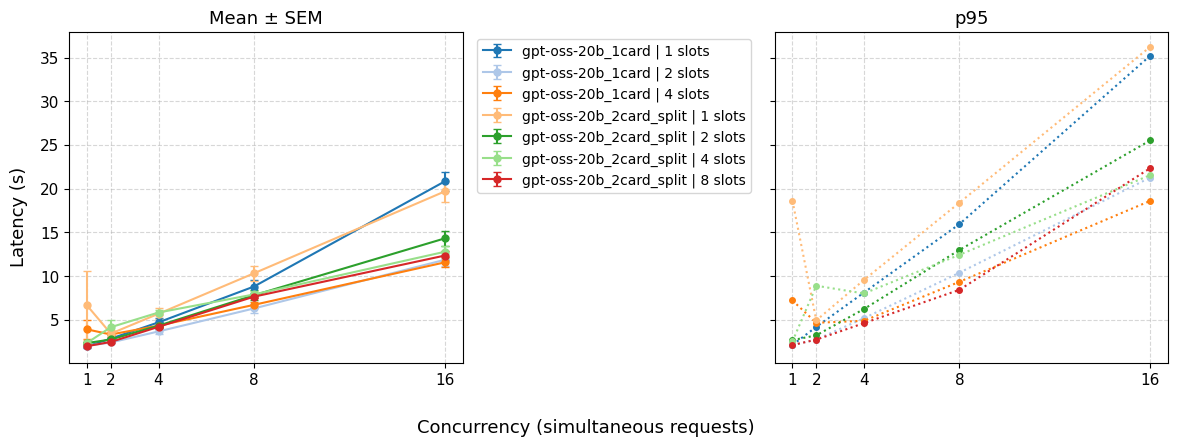

In [4]:
stats_by_config = summarize(data, ['config', 'concurrency'])

cmap = plt.get_cmap('tab20')
colors = [cmap(i) for i in range(len(configs))]
all_concurrencies = sorted(data['concurrency'].unique())

fig1, (ax_mean, ax_p95) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for i, config in enumerate(configs):
    subset = stats_by_config[stats_by_config['config'] == config].sort_values('concurrency')
    color = colors[i]

    ax_mean.errorbar(
        subset['concurrency'], subset['mean'],
        yerr=subset['sem'],
        marker='o', markersize=5, linewidth=1.5, linestyle='-',
        capsize=3, color=color, label=config,
    )

    ax_p95.plot(
        subset['concurrency'], subset['p95'],
        marker='o', markersize=4, linewidth=1.5, linestyle=':',
        color=color, label=config,
    )

for ax, title in [(ax_mean, 'Mean ± SEM'), (ax_p95, 'p95')]:
    ax.set_title(title)
    ax.set_xticks(all_concurrencies)
    ax.grid(True, linestyle='--', alpha=0.5)

ax_mean.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))
fig1.supxlabel('Concurrency (simultaneous requests)', fontsize=13)
fig1.supylabel('Latency (s)', fontsize=13)
fig1.tight_layout()

out1 = FIGURES_DIR / 'latency_vs_concurrency.png'
fig1.savefig(out1, dpi=150, bbox_inches='tight')
print(f'Saved {out1}')
plt.show()

## Plot 2: latency at target concurrency, by configuration

Useful for answering questions like: 'what is the best deployment profile when 8 requests land at once?'

Saved figures/latency_vs_config_c8.png


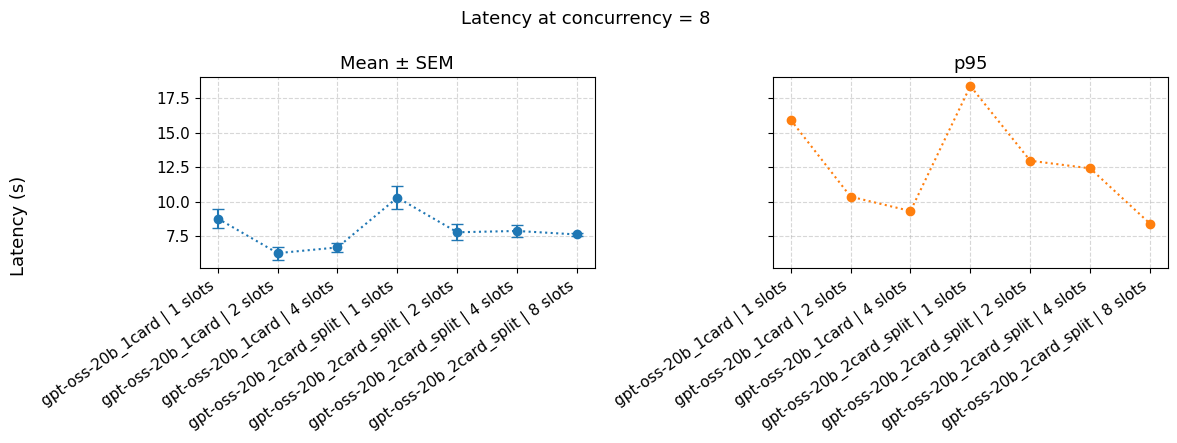

In [5]:
data_target = data[data['concurrency'] == TARGET_CONCURRENCY]

if data_target.empty:
    print(f'No data for concurrency={TARGET_CONCURRENCY}. Adjust TARGET_CONCURRENCY above.')
else:
    stats_target = summarize(data_target, ['config'])
    stats_target = stats_target.set_index('config').loc[configs].reset_index()

    fig2, (ax_mean, ax_p95) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    x = np.arange(len(stats_target))

    ax_mean.errorbar(
        x, stats_target['mean'],
        yerr=stats_target['sem'],
        marker='o', markersize=6, linewidth=1.5, linestyle='none',
        capsize=4, color=plt.get_cmap('tab10')(0),
    )
    ax_mean.plot(x, stats_target['mean'], linestyle=':', color=plt.get_cmap('tab10')(0))
    ax_mean.set_title('Mean ± SEM')

    ax_p95.plot(x, stats_target['p95'], marker='o', markersize=6, linewidth=1.5, linestyle=':', color=plt.get_cmap('tab10')(1))
    ax_p95.set_title('p95')

    labels = stats_target['config'].tolist()
    for ax in (ax_mean, ax_p95):
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=35, ha='right')
        ax.grid(True, linestyle='--', alpha=0.5)

    fig2.suptitle(f'Latency at concurrency = {TARGET_CONCURRENCY}', fontsize=13)
    fig2.supylabel('Latency (s)', fontsize=13)
    fig2.tight_layout()

    out2 = FIGURES_DIR / f'latency_vs_config_c{TARGET_CONCURRENCY}.png'
    fig2.savefig(out2, dpi=150, bbox_inches='tight')
    print(f'Saved {out2}')
    plt.show()

## Plot 3: context per slot, by configuration

Derived directly from the recorded `ctx_size` and `slots` columns. This replaces the old hard-coded bar chart.

Saved figures/context_per_slot.png


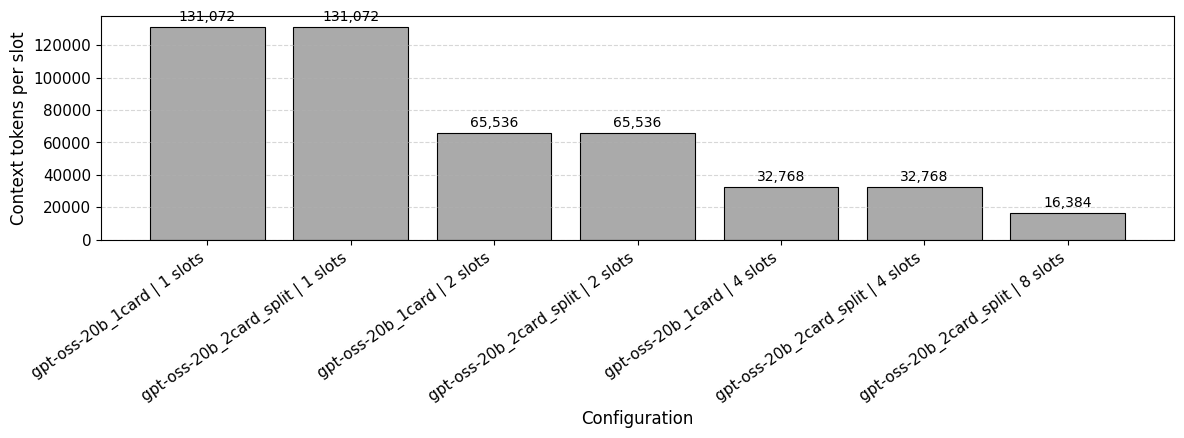

In [ ]:
configs_df = (
    data[['config', 'ctx_size', 'slots', 'ctx_per_slot']]
    .drop_duplicates()
    .sort_values(['ctx_per_slot', 'slots'], ascending=[False, True])
)

fig3, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(configs_df))
ax.bar(x, configs_df['ctx_per_slot'], color='#aaaaaa', edgecolor='black', linewidth=0.8)

for xi, ctx in zip(x, configs_df['ctx_per_slot']):
    ax.text(xi, ctx + configs_df['ctx_per_slot'].max() * 0.015, f'{int(ctx):,}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(configs_df['config'], rotation=35, ha='right')
ax.set_xlabel('Configuration')
ax.set_ylabel('Context tokens per slot')
ax.grid(axis='y', linestyle='--', alpha=0.5)
fig3.tight_layout()

out3 = FIGURES_DIR / 'context_per_slot.png'
fig3.savefig(out3, dpi=150, bbox_inches='tight')
print(f'Saved {out3}')
plt.show()

## Plot 4: saturated throughput, by configuration

For each configuration, use the rows where `concurrency == slots`.

If the CSV includes `batch_aggregate_tps`, this section reports **actual measured aggregate throughput** for each replicate batch. Otherwise it falls back to the older estimate:

`mean_request_tps_at_saturation × slots`

The table below indicates which mode was used for each configuration.

,config,ctx_size,slots,ctx_per_slot,mean_latency_s,p95_latency_s,mean_tokens,mean_request_tps,theoretical_aggregate_tps
0,gpt-oss-20b_1card | 1 slots,131072,1,131072,1.955,2.124,114.40,58.493,58.493
3,gpt-oss-20b_2card_split | 1 slots,131072,1,131072,6.642,18.626,127.00,39.547,39.547
1,gpt-oss-20b_1card | 2 slots,131072,2,65536,2.402,2.741,113.20,46.991,93.981
4,gpt-oss-20b_2card_split | 2 slots,131072,2,65536,2.744,3.219,111.10,40.329,80.658
2,gpt-oss-20b_1card | 4 slots,131072,4,32768,4.328,4.886,116.90,26.988,107.953
5,gpt-oss-20b_2card_split | 4 slots,131072,4,32768,5.831,8.009,117.60,20.627,82.510
6,gpt-oss-20b_2card_split | 8 slots,131072,8,16384,7.644,8.425,118.35,15.469,123.750


Saved figures/throughput_vs_config.png


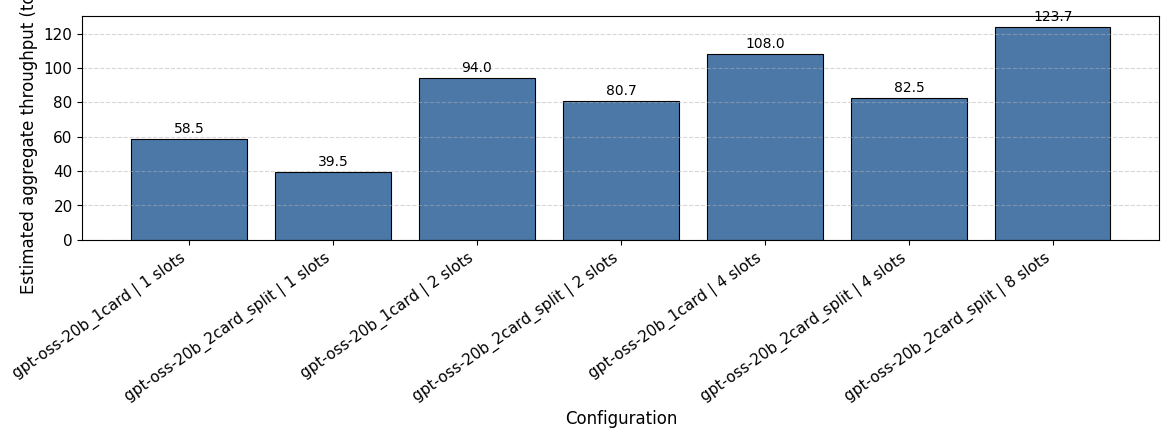

In [ ]:
saturated = data[data['concurrency'] == data['slots']].copy()

throughput_rows = []
for config, subset in saturated.groupby('config'):
    subset = subset.copy()
    exact_available = subset['batch_aggregate_tps'].notna().any()

    model = subset['model'].iloc[0]
    ctx_size = subset['ctx_size'].iloc[0]
    slots = int(subset['slots'].iloc[0])
    ctx_per_slot = subset['ctx_per_slot'].iloc[0]
    mean_latency_s = subset['latency_s'].mean()
    p95_latency_s = subset['latency_s'].quantile(0.95)
    mean_tokens = subset['tokens'].mean()
    mean_request_tps = subset['request_tps'].mean()

    if exact_available:
        per_batch = (
            subset[['replicate_id', 'batch_wall_s', 'batch_tokens', 'batch_success_count', 'batch_aggregate_tps']]
            .drop_duplicates()
            .dropna(subset=['batch_aggregate_tps'])
        )
        aggregate_tps = per_batch['batch_aggregate_tps'].mean()
        throughput_mode = 'measured'
    else:
        aggregate_tps = mean_request_tps * slots
        throughput_mode = 'estimated'

    throughput_rows.append({
        'config': config,
        'model': model,
        'ctx_size': ctx_size,
        'slots': slots,
        'ctx_per_slot': ctx_per_slot,
        'mean_latency_s': mean_latency_s,
        'p95_latency_s': p95_latency_s,
        'mean_tokens': mean_tokens,
        'mean_request_tps': mean_request_tps,
        'aggregate_tps': aggregate_tps,
        'throughput_mode': throughput_mode,
    })

throughput_table = pd.DataFrame(throughput_rows).sort_values('slots')

display(
    throughput_table[[
        'config', 'throughput_mode', 'ctx_size', 'slots', 'ctx_per_slot',
        'mean_latency_s', 'p95_latency_s', 'mean_tokens',
        'mean_request_tps', 'aggregate_tps',
    ]].round(3)
 )

fig4, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(throughput_table))
bar_colors = ['#4C78A8' if mode == 'measured' else '#9C755F' for mode in throughput_table['throughput_mode']]
ax.bar(x, throughput_table['aggregate_tps'], color=bar_colors, edgecolor='black', linewidth=0.8)

for xi, tps in zip(x, throughput_table['aggregate_tps']):
    ax.text(xi, tps + throughput_table['aggregate_tps'].max() * 0.015, f'{tps:.1f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(throughput_table['config'], rotation=35, ha='right')
ax.set_xlabel('Configuration')
ax.set_ylabel('Aggregate throughput (tok/s)')
ax.grid(axis='y', linestyle='--', alpha=0.5)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='#4C78A8', edgecolor='black', label='Measured batch throughput'),
    Patch(facecolor='#9C755F', edgecolor='black', label='Estimated throughput (legacy CSV)'),
]
ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.02, 1.0))
fig4.tight_layout()

out4 = FIGURES_DIR / 'throughput_vs_config.png'
fig4.savefig(out4, dpi=150, bbox_inches='tight')
print(f'Saved {out4}')
plt.show()